In [66]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import copy

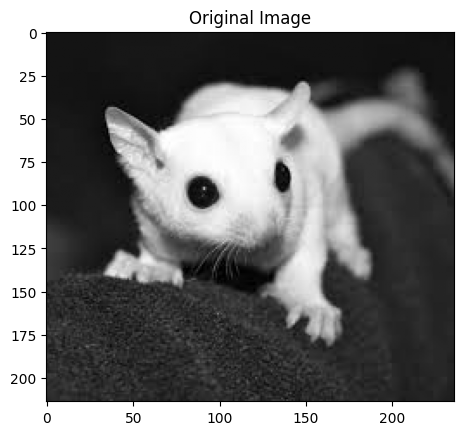

In [67]:
image = cv2.imread('normalpossum.jpeg', cv2.IMREAD_GRAYSCALE)

if image is None:
    print("Error: Could not load image. Please check the file path.")
else:
    image = image.astype(np.float64)

    plt.imshow(image, cmap='gray')
    plt.title("Original Image")
    plt.show()

In [68]:
def add_gaussian_noise(image, mean=0, std=1):
    noise = np.random.normal(mean, std, image.shape)
    noisy = image + noise
    return np.clip(noisy, 0, 255)

def add_rayleigh_noise(image, scale=1):
    noise = np.random.rayleigh(scale, image.shape)
    noisy = image + noise
    return np.clip(noisy, 0, 255)

def add_exponential_noise(image, scale=1):
    noise = np.random.exponential(scale, image.shape)
    noisy = image + noise
    return np.clip(noisy, 0, 255)

def add_uniform_noise(image, low=0, high=10):
    noise = np.random.uniform(low, high, image.shape)
    noisy = image + noise
    return np.clip(noisy, 0, 255)

def add_salt_pepper_noise(image, salt_prob=0.05, pepper_prob=0.05):
    noisy = image.copy()

    # Salt
    num_salt = int(salt_prob * image.size)
    coords = [np.random.randint(0, i, num_salt) for i in image.shape]
    noisy[coords[0], coords[1]] = 255

    # Pepper
    num_pepper = int(pepper_prob * image.size)
    coords = [np.random.randint(0, i, num_pepper) for i in image.shape]
    noisy[coords[0], coords[1]] = 0

    return noisy

In [69]:
def show_image_and_hist(img, title):
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(img, cmap='gray')
    plt.title(title)

    plt.subplot(1,2,2)
    plt.hist(img.ravel(), bins=256)
    plt.title("Histogram")

    plt.show()

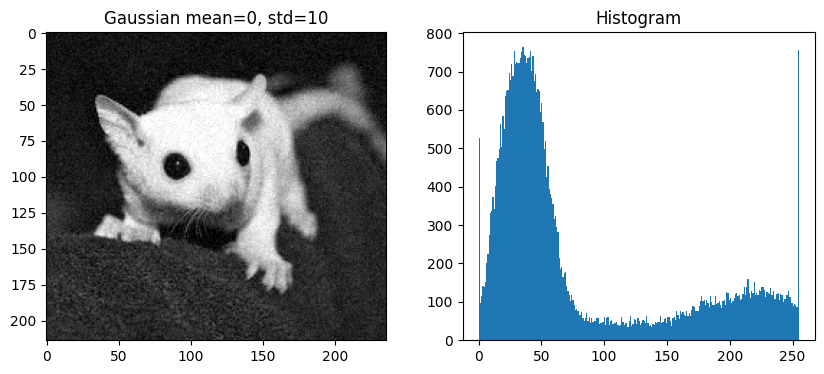

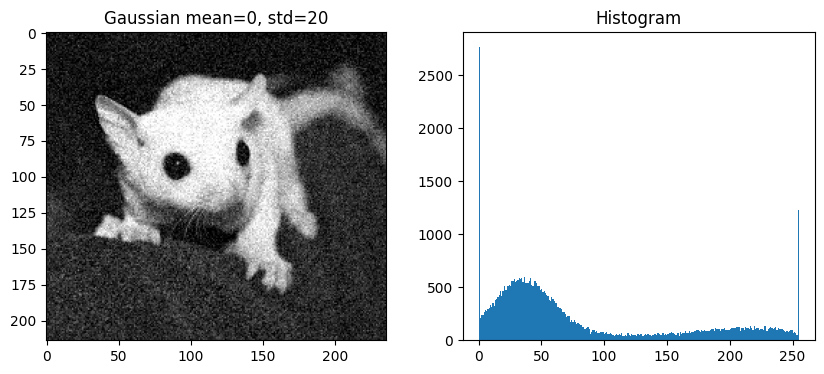

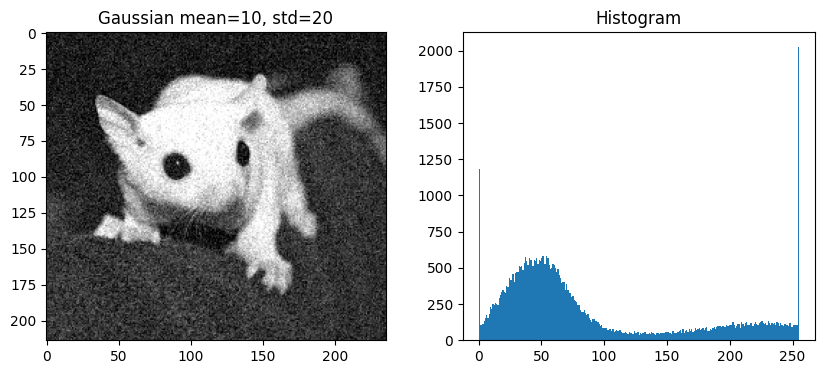

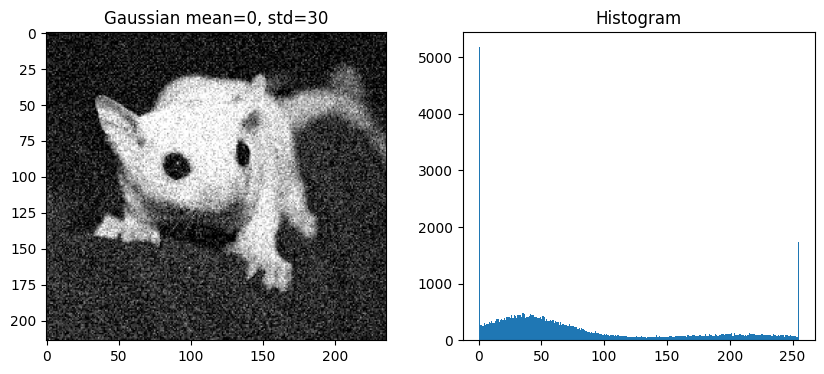

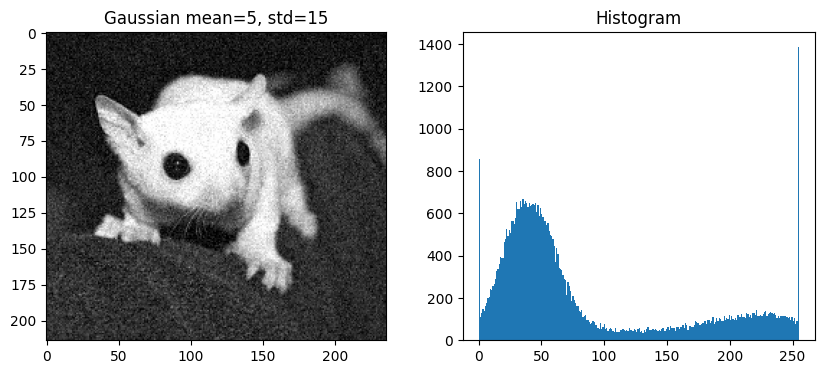

In [70]:
params = [(0,10),(0,20),(10,20),(0,30),(5,15)]

for mean, std in params:
    noisy = add_gaussian_noise(image, mean, std)
    show_image_and_hist(noisy, f"Gaussian mean={mean}, std={std}")

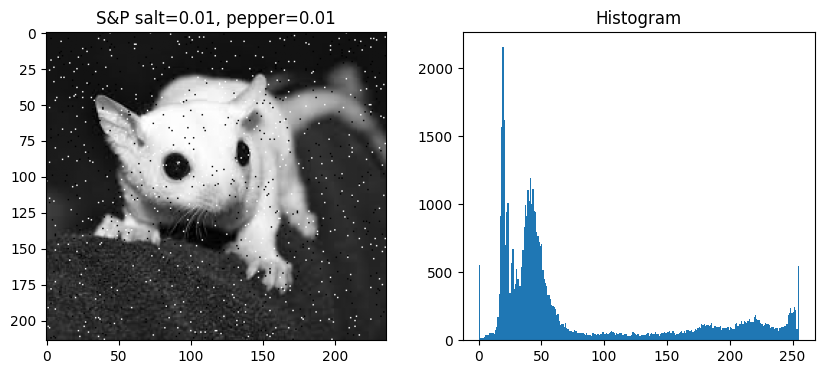

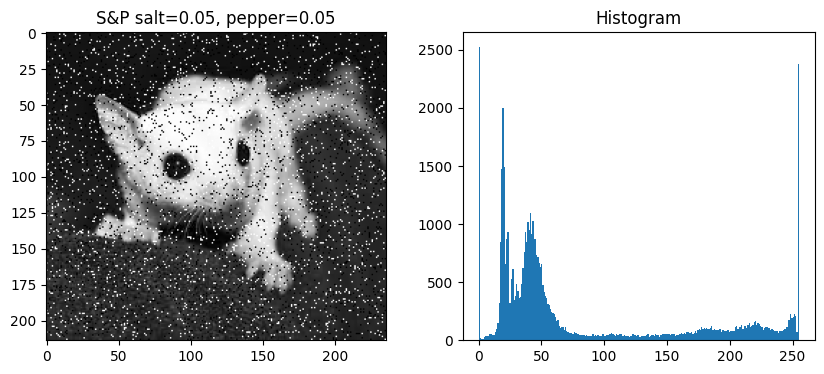

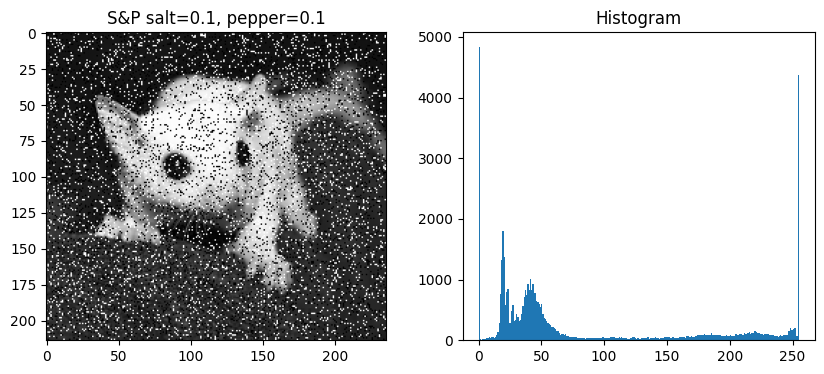

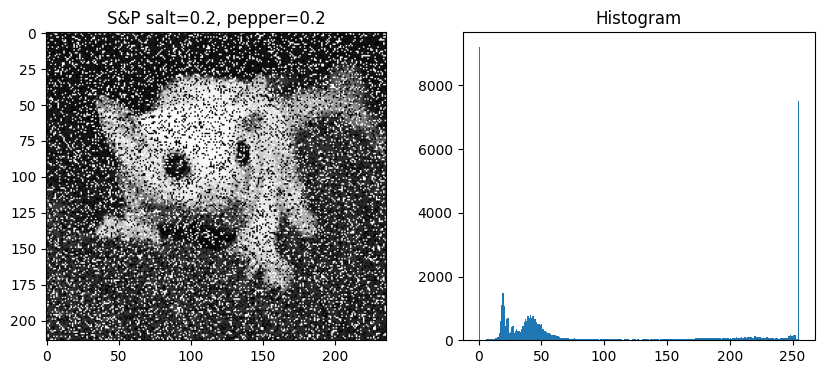

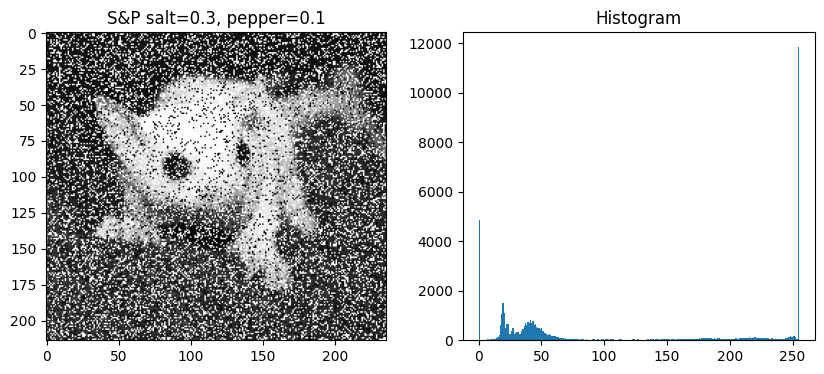

In [71]:
params = [(0.01,0.01),(0.05,0.05),(0.1,0.1),(0.2,0.2),(0.3,0.1)]

for s,p in params:
    noisy = add_salt_pepper_noise(image, s, p)
    show_image_and_hist(noisy, f"S&P salt={s}, pepper={p}")

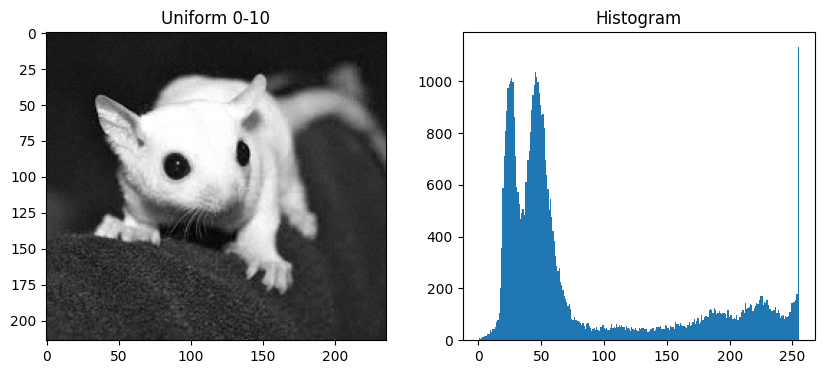

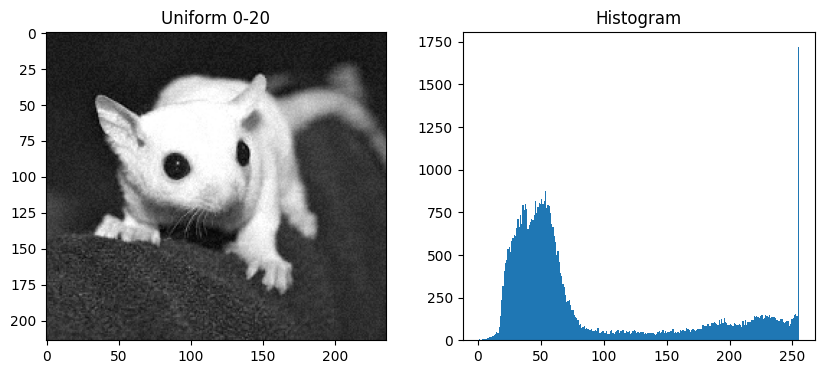

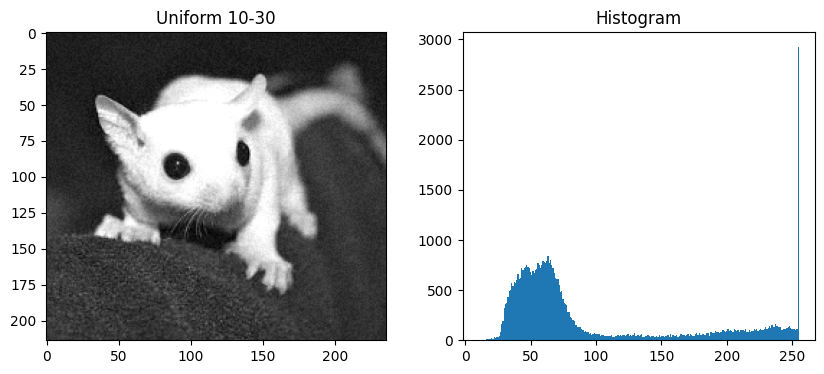

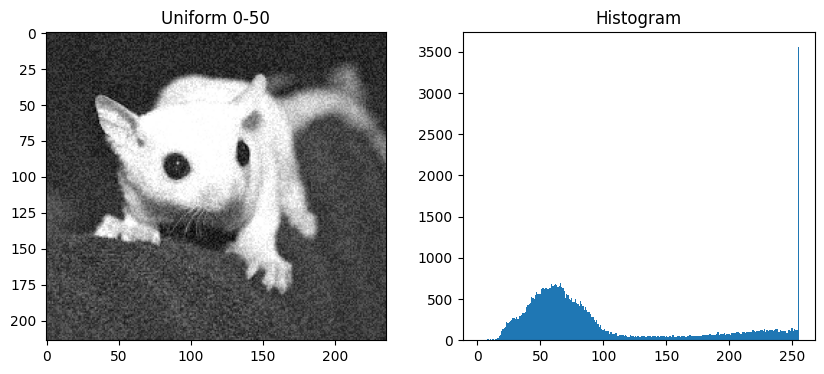

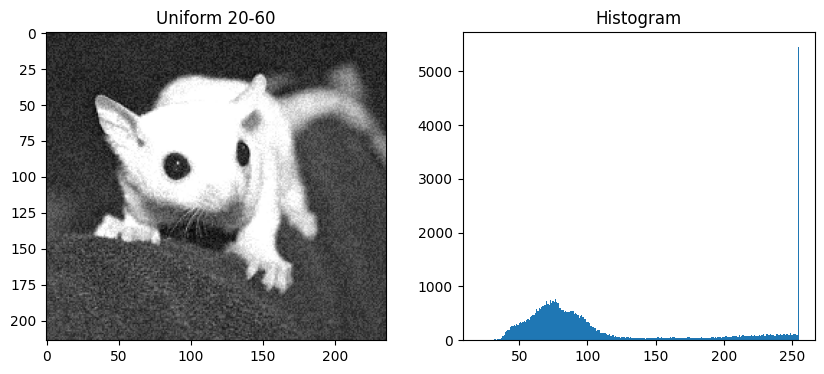

In [72]:
params = [(0,10),(0,20),(10,30),(0,50),(20,60)]

for low,high in params:
    noisy = add_uniform_noise(image, low, high)
    show_image_and_hist(noisy, f"Uniform {low}-{high}")

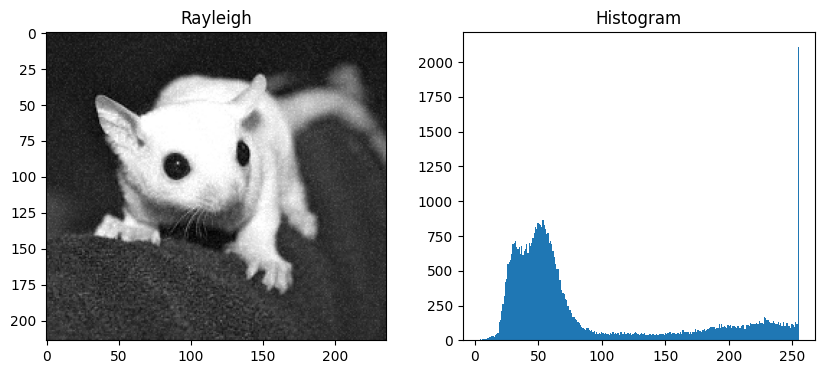

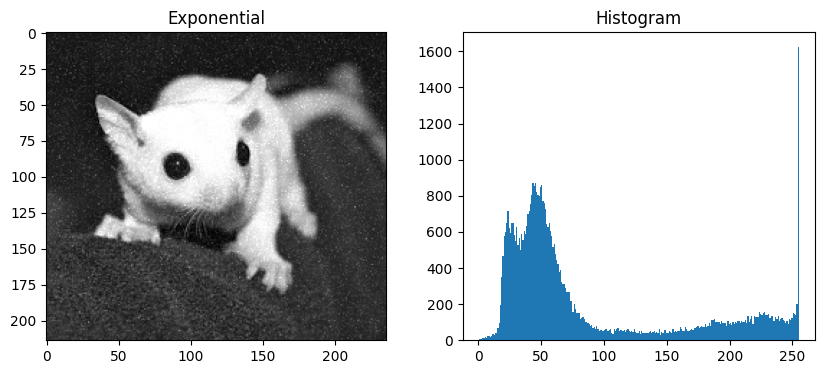

In [73]:
show_image_and_hist(add_rayleigh_noise(image, 10), "Rayleigh")
show_image_and_hist(add_exponential_noise(image, 10), "Exponential")

In [74]:
def apply_box(image_input, filt_size):
    pad = filt_size//2
    padded = np.pad(image_input, pad, mode='symmetric')
    output = np.zeros_like(image_input)

    for i in range(image_input.shape[0]):
        for j in range(image_input.shape[1]):
            patch = padded[i:i+filt_size, j:j+filt_size]
            output[i,j] = np.mean(patch)

    return output

In [75]:
def median_filter(image, size):
    pad = size//2
    padded = np.pad(image, pad, mode='symmetric')
    output = np.zeros_like(image)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            patch = padded[i:i+size, j:j+size]
            output[i,j] = np.median(patch)

    return output

In [76]:
def min_filter(image, size):
    pad = size//2
    padded = np.pad(image, pad, mode='symmetric')
    out = np.zeros_like(image)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            out[i,j] = np.min(padded[i:i+size, j:j+size])

    return out

def max_filter(image, size):
    pad = size//2
    padded = np.pad(image, pad, mode='symmetric')
    out = np.zeros_like(image)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            out[i,j] = np.max(padded[i:i+size, j:j+size])

    return out

In [77]:
def harmonic_mean_filter(image, size):
    pad = size//2
    padded = np.pad(image, pad, mode='symmetric')
    out = np.zeros_like(image)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            patch = padded[i:i+size, j:j+size]
            out[i,j] = (size*size) / np.sum(1/(patch+1e-5))

    return out

In [78]:
def geometric_mean_filter(image, size):
    pad = size//2
    padded = np.pad(image, pad, mode='symmetric')
    out = np.zeros_like(image)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            patch = padded[i:i+size, j:j+size]
            out[i,j] = np.exp(np.mean(np.log(patch+1)))

    return out

In [79]:
def contraharmonic_filter(image, size, Q):
    pad = size//2
    padded = np.pad(image, pad, mode='symmetric')
    out = np.zeros_like(image)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            patch = padded[i:i+size, j:j+size]
            num = np.sum(patch**(Q+1))
            den = np.sum(patch**Q)+1e-5
            out[i,j] = num/den

    return out

In [80]:
#task 2

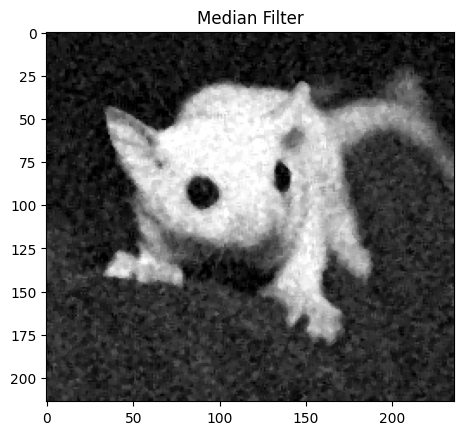

In [81]:
# Gaussian noise
noisy = add_gaussian_noise(image, 0, 30)

median = median_filter(noisy, 3)
mean3 = apply_box(noisy, 3)
mean5 = apply_box(noisy, 5)

plt.imshow(median, cmap='gray')
plt.title("Median Filter")
plt.show()

In [82]:
noisy = add_salt_pepper_noise(image, 0.1, 0.1)

minf = min_filter(noisy,5)
maxf = max_filter(noisy,5)
harm = harmonic_mean_filter(noisy,5)
geo = geometric_mean_filter(noisy,5)